In [1]:
import copy
import io
import math
import os
import random
import time
import urllib.request
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [2]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("A GPU is strongly recommended for the architecture sweep.")

Device: cuda
GPU: Tesla T4


In [3]:
DATA_FILE = "tiny_shakespeare.txt"

DATA_URL = (
    "https://raw.githubusercontent.com/karpathy/char-rnn/"
    "master/data/tinyshakespeare/input.txt"
)

if not os.path.exists(DATA_FILE):
    print("Downloading Tiny Shakespeare...")
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)

with open(DATA_FILE, "r", encoding="utf-8") as file:
    text = file.read()

print("Total characters:", len(text))
print("\nBeginning of dataset:\n")
print(text[:1000])

Total characters: 1115394

Beginning of dataset:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this

In [4]:
characters = sorted(list(set(text)))
vocab_size = len(characters)

char_to_index = {
    character: index
    for index, character in enumerate(characters)
}

index_to_char = {
    index: character
    for character, index in char_to_index.items()
}

encoded_text = torch.tensor(
    [char_to_index[character] for character in text],
    dtype=torch.long
)

print("Vocabulary size:", vocab_size)
print("Characters:")
print(characters)
print("\nFirst 50 encoded values:")
print(encoded_text[:50])

Vocabulary size: 65
Characters:
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

First 50 encoded values:
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56])


In [5]:
split_index = int(0.80 * len(encoded_text))

train_data = encoded_text[:split_index]
validation_data = encoded_text[split_index:]

print("Training characters:", len(train_data))
print("Validation characters:", len(validation_data))

print(
    "Training percentage:",
    round(100 * len(train_data) / len(encoded_text), 2)
)

print(
    "Validation percentage:",
    round(100 * len(validation_data) / len(encoded_text), 2)
)

Training characters: 892315
Validation characters: 223079
Training percentage: 80.0
Validation percentage: 20.0


In [6]:
def get_batch(
    data,
    sequence_length,
    batch_size,
    generator=None
):
    maximum_start = len(data) - sequence_length - 1

    starting_indices = torch.randint(
        low=0,
        high=maximum_start,
        size=(batch_size,),
        generator=generator
    )

    input_sequences = torch.stack([
        data[index:index + sequence_length]
        for index in starting_indices
    ])

    target_sequences = torch.stack([
        data[index + 1:index + sequence_length + 1]
        for index in starting_indices
    ])

    return (
        input_sequences.to(device),
        target_sequences.to(device)
    )

In [7]:
example_inputs, example_targets = get_batch(
    data=train_data,
    sequence_length=20,
    batch_size=2
)

def decode_indices(indices):
    return "".join(
        index_to_char[int(index)]
        for index in indices
    )

print("Input example:")
print(repr(decode_indices(example_inputs[0].cpu())))

print("\nTarget example:")
print(repr(decode_indices(example_targets[0].cpu())))

Input example:
'for jest.\n\nCAMILLO:\n'

Target example:
'or jest.\n\nCAMILLO:\nM'


In [8]:
class ShakespeareTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        maximum_sequence_length,
        d_model=128,
        number_of_heads=2,
        number_of_layers=2,
        feedforward_size=512,
        dropout=0.10
    ):
        super().__init__()

        if d_model % number_of_heads != 0:
            raise ValueError(
                "d_model must be divisible by number_of_heads."
            )

        self.vocab_size = vocab_size
        self.maximum_sequence_length = maximum_sequence_length
        self.d_model = d_model
        self.number_of_heads = number_of_heads
        self.number_of_layers = number_of_layers
        self.feedforward_size = feedforward_size

        self.character_embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.position_embedding = nn.Embedding(
            maximum_sequence_length,
            d_model
        )

        transformer_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=number_of_heads,
            dim_feedforward=feedforward_size,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=transformer_layer,
            num_layers=number_of_layers
        )

        self.final_normalization = nn.LayerNorm(d_model)

        self.output_layer = nn.Linear(
            d_model,
            vocab_size
        )

    def create_causal_mask(self, sequence_length, device):
        return torch.triu(
            torch.ones(
                sequence_length,
                sequence_length,
                dtype=torch.bool,
                device=device
            ),
            diagonal=1
        )

    def forward(self, input_sequence):
        batch_size, sequence_length = input_sequence.shape

        if sequence_length > self.maximum_sequence_length:
            raise ValueError(
                f"Input sequence length {sequence_length} exceeds "
                f"maximum length {self.maximum_sequence_length}."
            )

        positions = torch.arange(
            sequence_length,
            device=input_sequence.device
        ).unsqueeze(0)

        hidden_states = (
            self.character_embedding(input_sequence)
            + self.position_embedding(positions)
        )

        causal_mask = self.create_causal_mask(
            sequence_length,
            input_sequence.device
        )

        hidden_states = self.transformer(
            hidden_states,
            mask=causal_mask
        )

        hidden_states = self.final_normalization(
            hidden_states
        )

        logits = self.output_layer(hidden_states)

        return logits

In [9]:
test_model = ShakespeareTransformer(
    vocab_size=vocab_size,
    maximum_sequence_length=30,
    d_model=128,
    number_of_heads=2,
    number_of_layers=2,
    feedforward_size=512
).to(device)

test_input, test_target = get_batch(
    train_data,
    sequence_length=30,
    batch_size=8
)

test_logits = test_model(test_input)

print("Input shape:", test_input.shape)
print("Output shape:", test_logits.shape)

assert test_logits.shape == (
    8,
    30,
    vocab_size
)

print("Transformer test passed.")

Input shape: torch.Size([8, 30])
Output shape: torch.Size([8, 30, 65])
Transformer test passed.


In [10]:
def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def measure_model_size_megabytes(model):
    memory_buffer = io.BytesIO()

    torch.save(
        model.state_dict(),
        memory_buffer
    )

    number_of_bytes = memory_buffer.getbuffer().nbytes

    return number_of_bytes / (1024 ** 2)


print(
    "Trainable parameters:",
    f"{count_trainable_parameters(test_model):,}"
)

print(
    "Saved model size:",
    f"{measure_model_size_megabytes(test_model):.3f} MB"
)

Trainable parameters: 417,345
Saved model size: 1.602 MB


In [11]:
def approximate_transformer_macs(
    sequence_length,
    vocab_size,
    d_model,
    number_of_layers,
    feedforward_size
):
    projection_macs = (
        4 * sequence_length * d_model * d_model
    )

    attention_macs = (
        2 * sequence_length * sequence_length * d_model
    )

    feedforward_macs = (
        2
        * sequence_length
        * d_model
        * feedforward_size
    )

    macs_per_transformer_layer = (
        projection_macs
        + attention_macs
        + feedforward_macs
    )

    output_layer_macs = (
        sequence_length
        * d_model
        * vocab_size
    )

    total_macs = (
        number_of_layers
        * macs_per_transformer_layer
        + output_layer_macs
    )

    return total_macs

In [12]:
@torch.no_grad()
def evaluate_model(
    model,
    data,
    sequence_length,
    batch_size,
    number_of_batches=100
):
    model.eval()

    random_generator = torch.Generator()
    random_generator.manual_seed(SEED + 100)

    total_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for _ in range(number_of_batches):
        input_sequences, target_sequences = get_batch(
            data=data,
            sequence_length=sequence_length,
            batch_size=batch_size,
            generator=random_generator
        )

        logits = model(input_sequences)

        loss = F.cross_entropy(
            logits.reshape(-1, vocab_size),
            target_sequences.reshape(-1)
        )

        predictions = logits.argmax(dim=-1)

        total_loss += loss.item()

        correct_predictions += (
            predictions == target_sequences
        ).sum().item()

        total_predictions += target_sequences.numel()

    average_loss = total_loss / number_of_batches
    accuracy = correct_predictions / total_predictions
    perplexity = math.exp(min(average_loss, 20))

    return average_loss, accuracy, perplexity

In [13]:
@torch.no_grad()
def generate_text(
    model,
    starting_text,
    sequence_length,
    number_of_new_characters=300,
    temperature=0.8,
    top_k=20
):
    model.eval()

    generated_indices = [
        char_to_index.get(character, char_to_index[" "])
        for character in starting_text
    ]

    for _ in range(number_of_new_characters):
        current_context = generated_indices[-sequence_length:]

        input_tensor = torch.tensor(
            current_context,
            dtype=torch.long,
            device=device
        ).unsqueeze(0)

        logits = model(input_tensor)

        next_character_logits = (
            logits[:, -1, :] / temperature
        )

        if top_k is not None:
            top_values, _ = torch.topk(
                next_character_logits,
                min(top_k, vocab_size)
            )

            cutoff = top_values[:, -1].unsqueeze(1)

            next_character_logits = torch.where(
                next_character_logits < cutoff,
                torch.full_like(
                    next_character_logits,
                    float("-inf")
                ),
                next_character_logits
            )

        probabilities = F.softmax(
            next_character_logits,
            dim=-1
        )

        next_index = torch.multinomial(
            probabilities,
            num_samples=1
        ).item()

        generated_indices.append(next_index)

    return "".join(
        index_to_char[index]
        for index in generated_indices
    )

In [14]:
def synchronize_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


@torch.no_grad()
def measure_inference_time(
    model,
    sequence_length,
    repetitions=200
):
    model.eval()

    example_input = torch.randint(
        low=0,
        high=vocab_size,
        size=(1, sequence_length),
        device=device
    )

    for _ in range(20):
        _ = model(example_input)

    synchronize_device()

    start_time = time.perf_counter()

    for _ in range(repetitions):
        _ = model(example_input)

    synchronize_device()

    elapsed_time = time.perf_counter() - start_time

    return 1000 * elapsed_time / repetitions

In [15]:
QUICK_TEST = False

if QUICK_TEST:
    NUMBER_OF_EPOCHS = 2
    STEPS_PER_EPOCH = 25
    EVALUATION_BATCHES = 10
else:
    NUMBER_OF_EPOCHS = 8
    STEPS_PER_EPOCH = 300
    EVALUATION_BATCHES = 100


BATCH_SIZE = 64
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.10

print("Quick test:", QUICK_TEST)
print("Epochs:", NUMBER_OF_EPOCHS)
print("Steps per epoch:", STEPS_PER_EPOCH)
print("Evaluation batches:", EVALUATION_BATCHES)
print("Batch size:", BATCH_SIZE)

Quick test: False
Epochs: 8
Steps per epoch: 300
Evaluation batches: 100
Batch size: 64


In [16]:
def train_experiment(
    experiment_name,
    sequence_length,
    d_model,
    number_of_heads,
    number_of_layers,
    feedforward_size,
    epochs=NUMBER_OF_EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    dropout=DROPOUT
):
    print("\n" + "=" * 80)
    print("Experiment:", experiment_name)
    print(
        f"Length={sequence_length}, "
        f"d_model={d_model}, "
        f"heads={number_of_heads}, "
        f"layers={number_of_layers}, "
        f"d_ff={feedforward_size}"
    )
    print("=" * 80)

    set_seed()

    model = ShakespeareTransformer(
        vocab_size=vocab_size,
        maximum_sequence_length=sequence_length,
        d_model=d_model,
        number_of_heads=number_of_heads,
        number_of_layers=number_of_layers,
        feedforward_size=feedforward_size,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs * steps_per_epoch
    )

    use_mixed_precision = torch.cuda.is_available()

    scaler = torch.cuda.amp.GradScaler(
        enabled=use_mixed_precision
    )

    history = {
        "training_loss": [],
        "validation_loss": [],
        "validation_accuracy": [],
        "validation_perplexity": []
    }

    best_validation_loss = float("inf")
    best_epoch = 0
    best_model_state = None

    synchronize_device()
    training_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()

        epoch_loss = 0.0

        for _ in range(steps_per_epoch):
            input_sequences, target_sequences = get_batch(
                data=train_data,
                sequence_length=sequence_length,
                batch_size=batch_size
            )

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(
                enabled=use_mixed_precision
            ):
                logits = model(input_sequences)

                loss = F.cross_entropy(
                    logits.reshape(-1, vocab_size),
                    target_sequences.reshape(-1)
                )

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            epoch_loss += loss.item()

        average_training_loss = (
            epoch_loss / steps_per_epoch
        )

        (
            validation_loss,
            validation_accuracy,
            validation_perplexity
        ) = evaluate_model(
            model=model,
            data=validation_data,
            sequence_length=sequence_length,
            batch_size=batch_size,
            number_of_batches=EVALUATION_BATCHES
        )

        history["training_loss"].append(
            average_training_loss
        )

        history["validation_loss"].append(
            validation_loss
        )

        history["validation_accuracy"].append(
            validation_accuracy
        )

        history["validation_perplexity"].append(
            validation_perplexity
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch

            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:2d}/{epochs} | "
            f"Train Loss: {average_training_loss:.4f} | "
            f"Val Loss: {validation_loss:.4f} | "
            f"Val Accuracy: {100 * validation_accuracy:.2f}% | "
            f"Perplexity: {validation_perplexity:.3f}"
        )

    synchronize_device()

    training_time_seconds = (
        time.perf_counter() - training_start
    )

    model.load_state_dict(best_model_state)

    (
        final_validation_loss,
        final_validation_accuracy,
        final_validation_perplexity
    ) = evaluate_model(
        model=model,
        data=validation_data,
        sequence_length=sequence_length,
        batch_size=batch_size,
        number_of_batches=EVALUATION_BATCHES
    )

    parameter_count = count_trainable_parameters(model)

    model_size_mb = measure_model_size_megabytes(model)

    inference_time_ms = measure_inference_time(
        model,
        sequence_length
    )

    approximate_macs = approximate_transformer_macs(
        sequence_length=sequence_length,
        vocab_size=vocab_size,
        d_model=d_model,
        number_of_layers=number_of_layers,
        feedforward_size=feedforward_size
    )

    generated_sample = generate_text(
        model=model,
        starting_text="ROMEO:\n",
        sequence_length=sequence_length,
        number_of_new_characters=300,
        temperature=0.8,
        top_k=20
    )

    summary = {
        "Experiment": experiment_name,
        "Sequence Length": sequence_length,
        "Hidden Size": d_model,
        "Transformer Blocks": number_of_layers,
        "Attention Heads": number_of_heads,
        "Feedforward Size": feedforward_size,
        "Best Epoch": best_epoch,
        "Training Loss": history["training_loss"][best_epoch - 1],
        "Validation Loss": final_validation_loss,
        "Validation Accuracy (%)": (
            100 * final_validation_accuracy
        ),
        "Validation Perplexity": final_validation_perplexity,
        "Training Time (s)": training_time_seconds,
        "Inference Time (ms)": inference_time_ms,
        "Parameters": parameter_count,
        "Model Size (MB)": model_size_mb,
        "Approximate MACs": approximate_macs
    }

    print("\nGenerated sample:\n")
    print(generated_sample)

    model.cpu()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "summary": summary,
        "history": history,
        "generated_text": generated_sample,
        "state_dict": best_model_state
    }

In [17]:
all_experiments = {}

starting_configuration = {
    "d_model": 128,
    "number_of_heads": 2,
    "number_of_layers": 2,
    "feedforward_size": 512
}

for sequence_length in [20, 30]:
    experiment_name = (
        f"Baseline_L{sequence_length}_"
        f"B2_H2_D128"
    )

    all_experiments[experiment_name] = train_experiment(
        experiment_name=experiment_name,
        sequence_length=sequence_length,
        **starting_configuration
    )


Experiment: Baseline_L20_B2_H2_D128
Length=20, d_model=128, heads=2, layers=2, d_ff=512
Epoch  1/8 | Train Loss: 2.6939 | Val Loss: 2.3628 | Val Accuracy: 32.38% | Perplexity: 10.621
Epoch  2/8 | Train Loss: 2.2744 | Val Loss: 2.2079 | Val Accuracy: 36.07% | Perplexity: 9.097
Epoch  3/8 | Train Loss: 2.1620 | Val Loss: 2.1278 | Val Accuracy: 37.63% | Perplexity: 8.396
Epoch  4/8 | Train Loss: 2.1025 | Val Loss: 2.0938 | Val Accuracy: 38.43% | Perplexity: 8.116
Epoch  5/8 | Train Loss: 2.0698 | Val Loss: 2.0672 | Val Accuracy: 39.04% | Perplexity: 7.903
Epoch  6/8 | Train Loss: 2.0464 | Val Loss: 2.0568 | Val Accuracy: 39.21% | Perplexity: 7.821
Epoch  7/8 | Train Loss: 2.0412 | Val Loss: 2.0503 | Val Accuracy: 39.46% | Perplexity: 7.770
Epoch  8/8 | Train Loss: 2.0330 | Val Loss: 2.0497 | Val Accuracy: 39.46% | Perplexity: 7.766

Generated sample:

ROMEO:
By giome.

YORY:
Whew his caddyse misune you kize, ad and not deathe frown sor my son'e love matter the aur to been
We then bout be

In [18]:
sequence_length_rows = []

for experiment_name in [
    "Baseline_L20_B2_H2_D128",
    "Baseline_L30_B2_H2_D128"
]:
    sequence_length_rows.append(
        all_experiments[experiment_name]["summary"]
    )

sequence_length_results = pd.DataFrame(
    sequence_length_rows
)

sequence_length_results.round({
    "Training Loss": 4,
    "Validation Loss": 4,
    "Validation Accuracy (%)": 2,
    "Validation Perplexity": 3,
    "Training Time (s)": 2,
    "Inference Time (ms)": 4,
    "Model Size (MB)": 3
})

,Experiment,Sequence Length,Hidden Size,Transformer Blocks,Attention Heads,Feedforward Size,Best Epoch,Training Loss,Validation Loss,Validation Accuracy (%),Validation Perplexity,Training Time (s),Inference Time (ms),Parameters,Model Size (MB),Approximate MACs
0,Baseline_L20_B2_H2_D128,20,128,2,2,512,8,2.0330,2.0497,39.46,7.766,28.55,1.1959,416065,1.598,8235520
1,Baseline_L30_B2_H2_D128,30,128,2,2,512,8,2.0194,2.0268,39.61,7.590,27.14,1.1087,417345,1.602,12506880


In [19]:
sequence_length_results.to_csv(
    "problem2_sequence_length_results.csv",
    index=False
)

print("Saved: problem2_sequence_length_results.csv")

Saved: problem2_sequence_length_results.csv


In [20]:
ARCHITECTURE_CONFIGURATIONS = [
    {
        "name": "B1_H2_D128",
        "d_model": 128,
        "number_of_heads": 2,
        "number_of_layers": 1,
        "feedforward_size": 512
    },
    {
        "name": "B1_H4_D128",
        "d_model": 128,
        "number_of_heads": 4,
        "number_of_layers": 1,
        "feedforward_size": 512
    },
    {
        "name": "B2_H2_D128",
        "d_model": 128,
        "number_of_heads": 2,
        "number_of_layers": 2,
        "feedforward_size": 512
    },
    {
        "name": "B2_H4_D128",
        "d_model": 128,
        "number_of_heads": 4,
        "number_of_layers": 2,
        "feedforward_size": 512
    },
    {
        "name": "B4_H2_D128",
        "d_model": 128,
        "number_of_heads": 2,
        "number_of_layers": 4,
        "feedforward_size": 512
    },
    {
        "name": "B4_H4_D128",
        "d_model": 128,
        "number_of_heads": 4,
        "number_of_layers": 4,
        "feedforward_size": 512
    },
    {
        "name": "B2_H2_D64",
        "d_model": 64,
        "number_of_heads": 2,
        "number_of_layers": 2,
        "feedforward_size": 256
    },
    {
        "name": "B2_H2_D256",
        "d_model": 256,
        "number_of_heads": 2,
        "number_of_layers": 2,
        "feedforward_size": 1024
    }
]

architecture_table = pd.DataFrame(
    ARCHITECTURE_CONFIGURATIONS
)

architecture_table

,name,d_model,number_of_heads,number_of_layers,feedforward_size
0,B1_H2_D128,128,2,1,512
1,B1_H4_D128,128,4,1,512
2,B2_H2_D128,128,2,2,512
3,B2_H4_D128,128,4,2,512
4,B4_H2_D128,128,2,4,512
5,B4_H4_D128,128,4,4,512
6,B2_H2_D64,64,2,2,256
7,B2_H2_D256,256,2,2,1024


In [21]:
ARCHITECTURE_SEQUENCE_LENGTH = 30

architecture_experiments = {}

for configuration in ARCHITECTURE_CONFIGURATIONS:
    short_name = configuration["name"]

    if short_name == "B2_H2_D128":
        existing_name = "Baseline_L30_B2_H2_D128"

        architecture_experiments[short_name] = (
            all_experiments[existing_name]
        )

        print(
            "\nReusing previously trained model:",
            existing_name
        )

        continue

    full_experiment_name = (
        f"Sweep_L30_{short_name}"
    )

    architecture_experiments[short_name] = train_experiment(
        experiment_name=full_experiment_name,
        sequence_length=ARCHITECTURE_SEQUENCE_LENGTH,
        d_model=configuration["d_model"],
        number_of_heads=configuration["number_of_heads"],
        number_of_layers=configuration["number_of_layers"],
        feedforward_size=configuration["feedforward_size"]
    )


Experiment: Sweep_L30_B1_H2_D128
Length=30, d_model=128, heads=2, layers=1, d_ff=512
Epoch  1/8 | Train Loss: 2.7872 | Val Loss: 2.4249 | Val Accuracy: 31.00% | Perplexity: 11.301
Epoch  2/8 | Train Loss: 2.3411 | Val Loss: 2.2726 | Val Accuracy: 34.36% | Perplexity: 9.705
Epoch  3/8 | Train Loss: 2.2426 | Val Loss: 2.2105 | Val Accuracy: 35.62% | Perplexity: 9.120
Epoch  4/8 | Train Loss: 2.1974 | Val Loss: 2.1790 | Val Accuracy: 36.15% | Perplexity: 8.838
Epoch  5/8 | Train Loss: 2.1664 | Val Loss: 2.1607 | Val Accuracy: 36.58% | Perplexity: 8.677
Epoch  6/8 | Train Loss: 2.1501 | Val Loss: 2.1481 | Val Accuracy: 36.79% | Perplexity: 8.569
Epoch  7/8 | Train Loss: 2.1420 | Val Loss: 2.1439 | Val Accuracy: 36.92% | Perplexity: 8.533
Epoch  8/8 | Train Loss: 2.1419 | Val Loss: 2.1430 | Val Accuracy: 36.92% | Perplexity: 8.525

Generated sample:

ROMEO:
Pay to the wess. She bulst do sere us, to that the farke you, then, and prive but my his my of is arng ante wayour that on the habl my

In [22]:
architecture_rows = []

for configuration in ARCHITECTURE_CONFIGURATIONS:
    short_name = configuration["name"]

    row = architecture_experiments[
        short_name
    ]["summary"].copy()

    row["Configuration"] = short_name

    architecture_rows.append(row)

architecture_results = pd.DataFrame(
    architecture_rows
)

architecture_results = architecture_results[[
    "Configuration",
    "Sequence Length",
    "Hidden Size",
    "Transformer Blocks",
    "Attention Heads",
    "Feedforward Size",
    "Best Epoch",
    "Training Loss",
    "Validation Loss",
    "Validation Accuracy (%)",
    "Validation Perplexity",
    "Training Time (s)",
    "Inference Time (ms)",
    "Parameters",
    "Model Size (MB)",
    "Approximate MACs"
]]

architecture_results.round({
    "Training Loss": 4,
    "Validation Loss": 4,
    "Validation Accuracy (%)": 2,
    "Validation Perplexity": 3,
    "Training Time (s)": 2,
    "Inference Time (ms)": 4,
    "Model Size (MB)": 3
})

,Configuration,Sequence Length,Hidden Size,Transformer Blocks,Attention Heads,Feedforward Size,Best Epoch,Training Loss,Validation Loss,Validation Accuracy (%),Validation Perplexity,Training Time (s),Inference Time (ms),Parameters,Model Size (MB),Approximate MACs
0,B1_H2_D128,30,128,1,2,512,8,2.1419,2.1430,36.92,8.525,21.26,0.7489,219073,0.842,6378240
1,B1_H4_D128,30,128,1,4,512,8,2.1244,2.1282,37.29,8.400,20.02,0.7585,219073,0.842,6378240
2,B2_H2_D128,30,128,2,2,512,8,2.0194,2.0268,39.61,7.590,27.14,1.1087,417345,1.602,12506880
3,B2_H4_D128,30,128,2,4,512,8,2.0091,2.0204,39.71,7.541,26.74,1.2081,417345,1.602,12506880
4,B4_H2_D128,30,128,4,2,512,8,1.9037,1.9427,42.42,6.978,41.63,2.6358,813889,3.124,24764160
5,B4_H4_D128,30,128,4,4,512,8,1.9072,1.9510,42.09,7.036,40.41,1.8660,813889,3.124,24764160
6,B2_H2_D64,30,64,2,2,256,8,2.2548,2.2273,35.42,9.275,26.57,1.1749,110401,0.432,3304320
7,B2_H2_D256,30,256,2,2,1024,8,1.7939,1.8738,44.56,6.513,27.74,1.6204,1621057,6.194,48606720


In [23]:
architecture_results.to_csv(
    "problem2_architecture_results.csv",
    index=False
)

print("Saved: problem2_architecture_results.csv")

Saved: problem2_architecture_results.csv


In [24]:
ranked_architectures = architecture_results.sort_values(
    by="Validation Loss",
    ascending=True
).reset_index(drop=True)

ranked_architectures.round({
    "Training Loss": 4,
    "Validation Loss": 4,
    "Validation Accuracy (%)": 2,
    "Validation Perplexity": 3,
    "Training Time (s)": 2,
    "Inference Time (ms)": 4,
    "Model Size (MB)": 3
})

,Configuration,Sequence Length,Hidden Size,Transformer Blocks,Attention Heads,Feedforward Size,Best Epoch,Training Loss,Validation Loss,Validation Accuracy (%),Validation Perplexity,Training Time (s),Inference Time (ms),Parameters,Model Size (MB),Approximate MACs
0,B2_H2_D256,30,256,2,2,1024,8,1.7939,1.8738,44.56,6.513,27.74,1.6204,1621057,6.194,48606720
1,B4_H2_D128,30,128,4,2,512,8,1.9037,1.9427,42.42,6.978,41.63,2.6358,813889,3.124,24764160
2,B4_H4_D128,30,128,4,4,512,8,1.9072,1.9510,42.09,7.036,40.41,1.8660,813889,3.124,24764160
3,B2_H4_D128,30,128,2,4,512,8,2.0091,2.0204,39.71,7.541,26.74,1.2081,417345,1.602,12506880
4,B2_H2_D128,30,128,2,2,512,8,2.0194,2.0268,39.61,7.590,27.14,1.1087,417345,1.602,12506880
5,B1_H4_D128,30,128,1,4,512,8,2.1244,2.1282,37.29,8.400,20.02,0.7585,219073,0.842,6378240
6,B1_H2_D128,30,128,1,2,512,8,2.1419,2.1430,36.92,8.525,21.26,0.7489,219073,0.842,6378240
7,B2_H2_D64,30,64,2,2,256,8,2.2548,2.2273,35.42,9.275,26.57,1.1749,110401,0.432,3304320


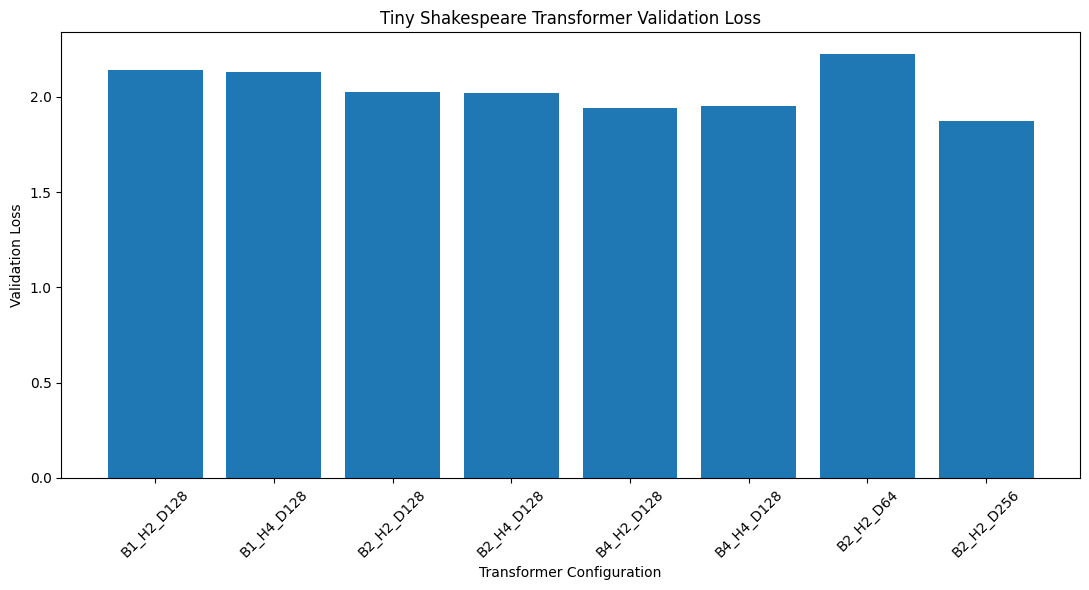

In [25]:
plt.figure(figsize=(11, 6))

plt.bar(
    architecture_results["Configuration"],
    architecture_results["Validation Loss"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Validation Loss")
plt.title("Tiny Shakespeare Transformer Validation Loss")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem2_architecture_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

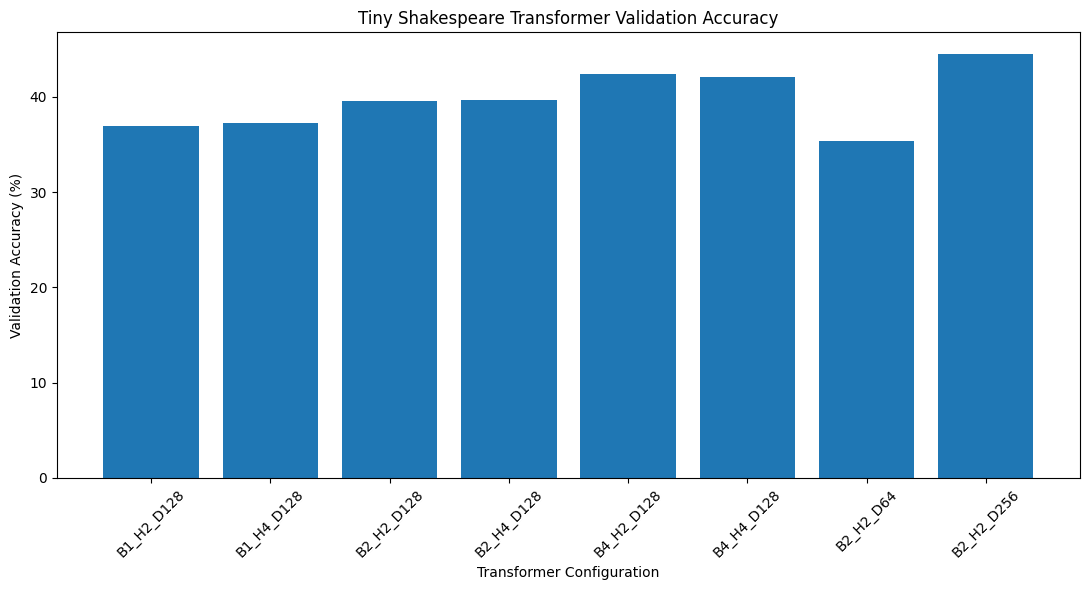

In [26]:
plt.figure(figsize=(11, 6))

plt.bar(
    architecture_results["Configuration"],
    architecture_results["Validation Accuracy (%)"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Validation Accuracy (%)")
plt.title("Tiny Shakespeare Transformer Validation Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem2_architecture_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

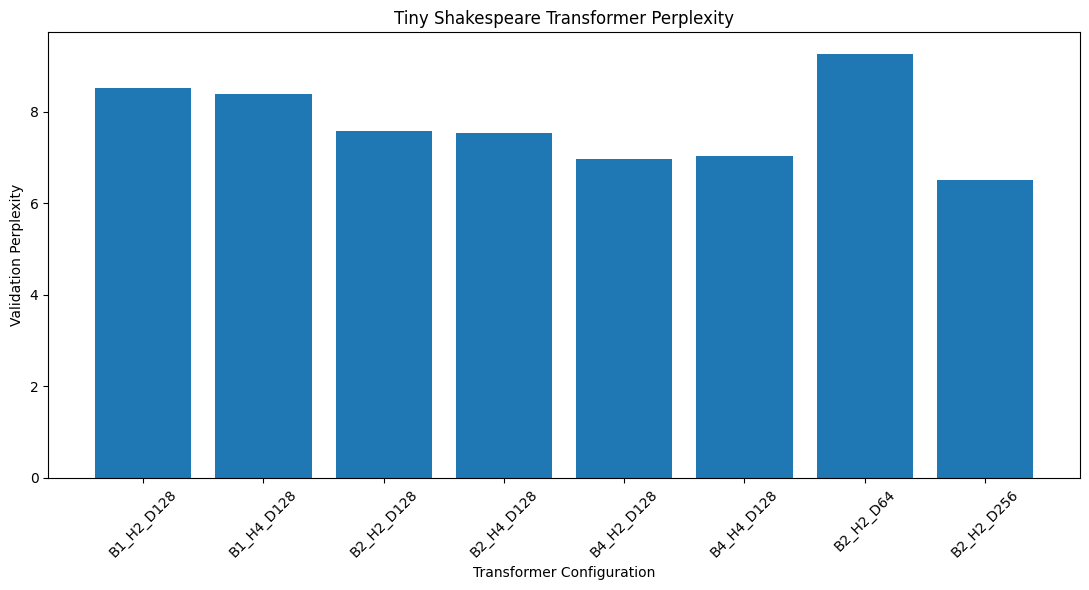

In [27]:
plt.figure(figsize=(11, 6))

plt.bar(
    architecture_results["Configuration"],
    architecture_results["Validation Perplexity"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Validation Perplexity")
plt.title("Tiny Shakespeare Transformer Perplexity")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem2_architecture_perplexity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

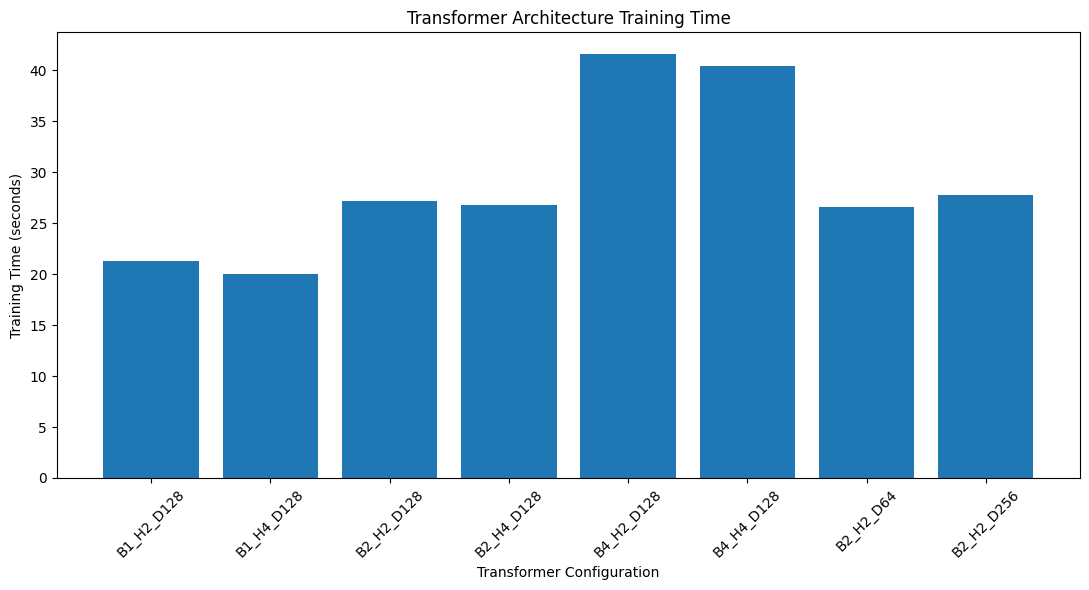

In [28]:
plt.figure(figsize=(11, 6))

plt.bar(
    architecture_results["Configuration"],
    architecture_results["Training Time (s)"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Training Time (seconds)")
plt.title("Transformer Architecture Training Time")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem2_architecture_training_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

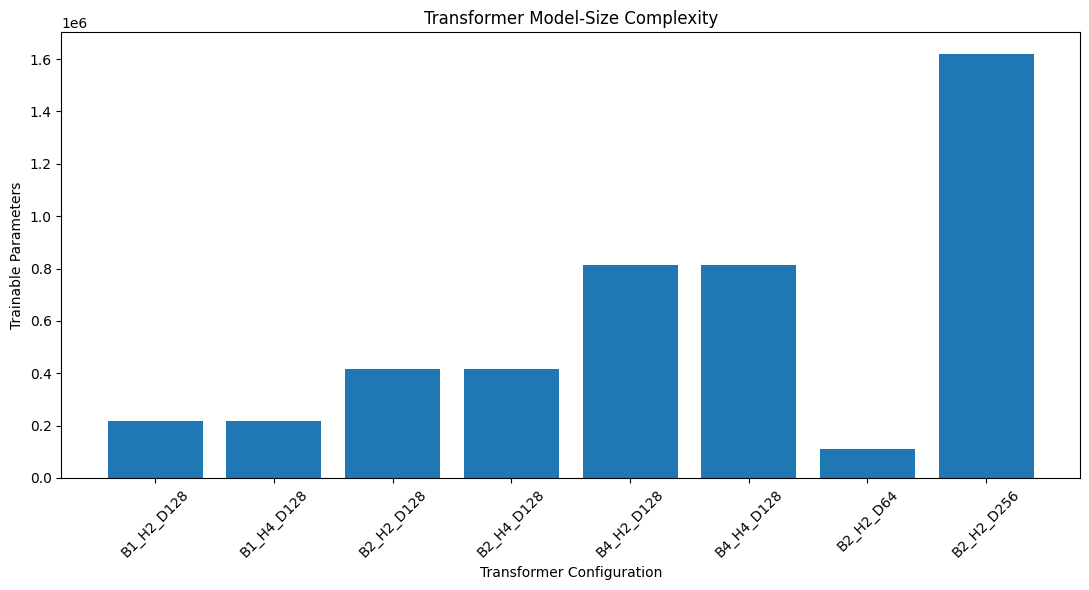

In [29]:
plt.figure(figsize=(11, 6))

plt.bar(
    architecture_results["Configuration"],
    architecture_results["Parameters"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Trainable Parameters")
plt.title("Transformer Model-Size Complexity")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem2_architecture_parameters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

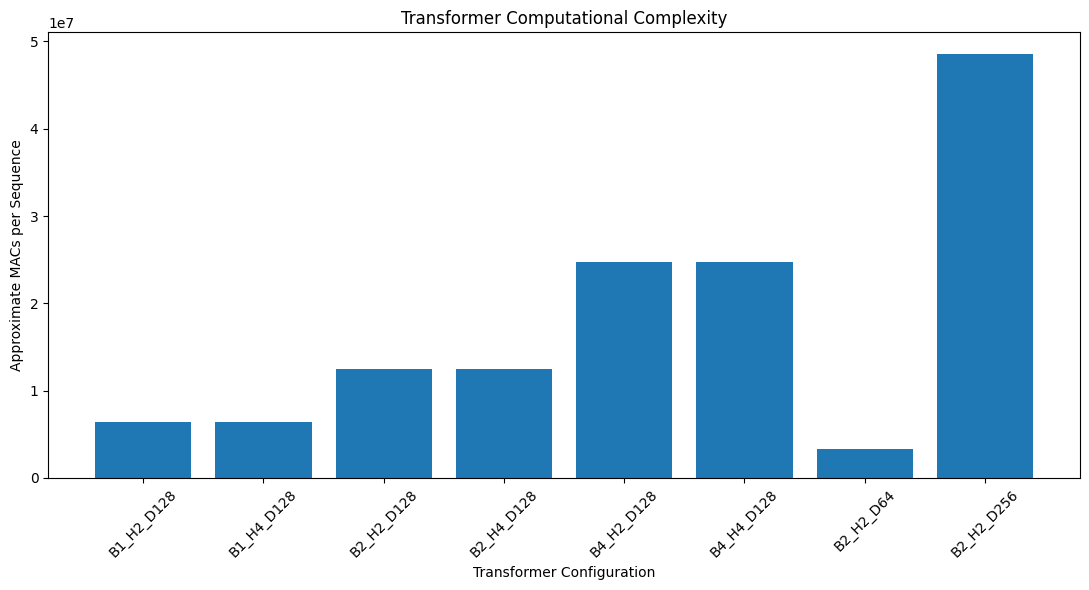

In [30]:
plt.figure(figsize=(11, 6))

plt.bar(
    architecture_results["Configuration"],
    architecture_results["Approximate MACs"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Approximate MACs per Sequence")
plt.title("Transformer Computational Complexity")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem2_architecture_macs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

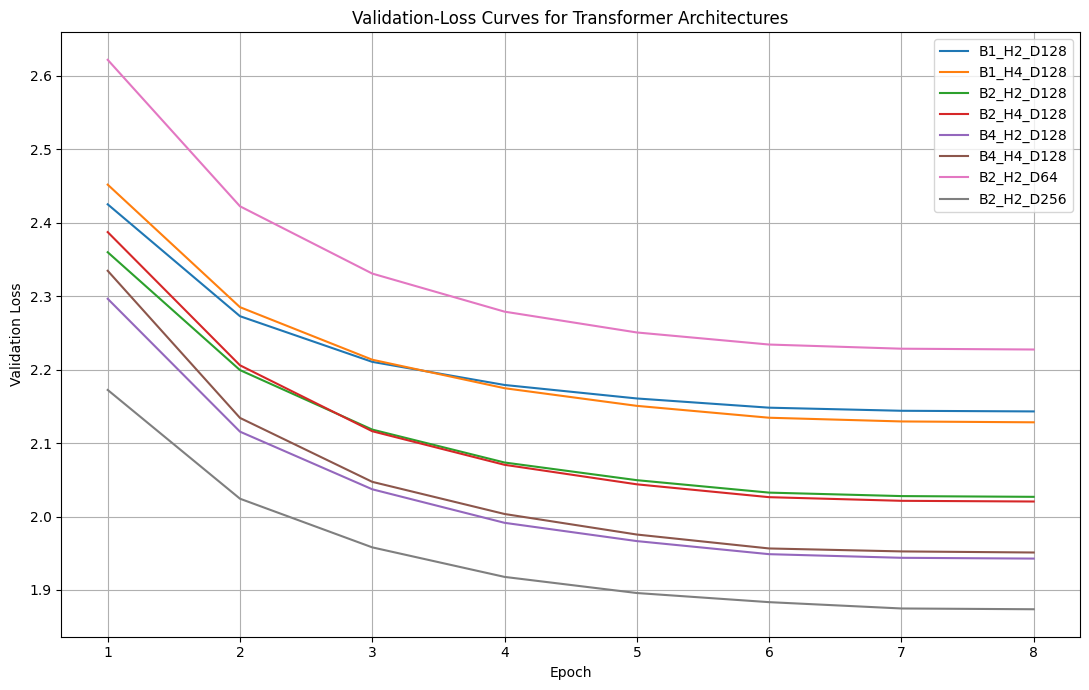

In [31]:
plt.figure(figsize=(11, 7))

for configuration in ARCHITECTURE_CONFIGURATIONS:
    name = configuration["name"]

    history = architecture_experiments[
        name
    ]["history"]

    epochs = range(
        1,
        len(history["validation_loss"]) + 1
    )

    plt.plot(
        epochs,
        history["validation_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation-Loss Curves for Transformer Architectures")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "problem2_all_validation_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
generated_text_rows = []

for configuration in ARCHITECTURE_CONFIGURATIONS:
    name = configuration["name"]

    generated_text_rows.append({
        "Configuration": name,
        "Generated Text": architecture_experiments[
            name
        ]["generated_text"]
    })

generated_text_results = pd.DataFrame(
    generated_text_rows
)

pd.set_option("display.max_colwidth", 500)

generated_text_results

,Configuration,Generated Text
0,B1_H2_D128,"ROMEO:\nPay to the wess. She bulst do sere us, to that the farke you, then, and prive but my his my of is arng ante wayour that on the habl my the fordes of grown itheire ind mavee;\nA looke, gosedy dose all hathe streid not wither you this? Mall men the and atere will the wit.\n\nWO, thoms this in will yought"
1,B1_H4_D128,"ROMEO:\nSe to hit the dit the my of the brothery sour by toiknges thear the prown oull is powsl mand ount pard hate in to so sord.\n\nLevengthe the took whe wor athe kin thans pone our den.\n\nTo ford, intthe anie of in cun and the ware andiould with ble sut bate soright me now lands, she cthand haste mreay of"
2,B2_H2_D128,"ROMEO:\nShalt hy good, and I I that you, fathen thear a in the mest the france, muke hop is the come, be havand comme.\n\nGrode his fanters and wadue clone.\n\nFOOF Lord witing is and pup the could not say a that earl gemas mord corteave a fiing bond hathe her's mies mall muse pearpongs bartive you come you the"
3,B2_H4_D128,"ROMEO:\nThe he here for thing age to do reat we the heres we morly we the theing of shald;\nAs we bold what wis have call the, to me bother wirk, by dome:\nNinown cold to die so de, of I let be this be be the ir hat our sord's?\n\nMENENIUS:\nGo sir:\nAnd fomer of faing and are, wher\nWhath the he prace condiers la"
4,B4_H2_D128,"ROMEO:\nNo, my not sair that ment the come the crain tany whith siceds not domess\nAs I must thou pleasi.\n\nThe comest for madinst to but the with most o'ther to the you gret\nThe will so the hod he such so this revandess death ince the hathere that speace are.\n\nFORIO:\nSo I pliseder's waine is that two that ou"
5,B4_H4_D128,"ROMEO:\nWhat are mant to sut loven is desself,\nIf him? and so be heave same to throthere,\nI for their cant artheign, what mets to a the gate your bottruted of or hy best,\nWhat thee or king betheir son.\n\nCORHARD IV:\nAll trom tore that ce this of though,\nAnd mest so wast his fore mingurs the the of not the go"
6,B2_H2_D64,"ROMEO:\nY:\nGorer you fart the mit lorde blorld, as,\nAnd wetikn pre llaim hearces woull inghowsl mand on.\n\nBOLIUMARD RIIINGARY:\nPard te cover heme took wheave, athe bir thand pon all and my foll that utthe maie or ing st do lired, an andiot ar by cald suth thearn:\nThe me noo lenos, shest hand hasde mre arot"
7,B2_H2_D256,"ROMEO:\nYou, but the speacs, this gate the well: I heor have most me offer it of their upon be of it for the save that dows well my that. Lorvice I will not majest,\nAs not that not the do'st part of my strupon the pricted bear should him him her your all for mord a hind when,\nIn I will the more your of stim"


In [33]:
generated_text_results.to_csv(
    "problem2_generated_text_samples.csv",
    index=False
)

print("Saved: problem2_generated_text_samples.csv")

Saved: problem2_generated_text_samples.csv


In [34]:
best_architecture_name = ranked_architectures.loc[
    0,
    "Configuration"
]

best_configuration = next(
    configuration
    for configuration in ARCHITECTURE_CONFIGURATIONS
    if configuration["name"] == best_architecture_name
)

print("Best architecture:", best_architecture_name)
print(best_configuration)

Best architecture: B2_H2_D256
{'name': 'B2_H2_D256', 'd_model': 256, 'number_of_heads': 2, 'number_of_layers': 2, 'feedforward_size': 1024}


In [35]:
sequence_50_experiment_name = (
    f"BestArchitecture_L50_{best_architecture_name}"
)

sequence_50_result = train_experiment(
    experiment_name=sequence_50_experiment_name,
    sequence_length=50,
    d_model=best_configuration["d_model"],
    number_of_heads=best_configuration["number_of_heads"],
    number_of_layers=best_configuration["number_of_layers"],
    feedforward_size=best_configuration["feedforward_size"]
)


Experiment: BestArchitecture_L50_B2_H2_D256
Length=50, d_model=256, heads=2, layers=2, d_ff=1024
Epoch  1/8 | Train Loss: 2.4516 | Val Loss: 2.1771 | Val Accuracy: 35.84% | Perplexity: 8.821
Epoch  2/8 | Train Loss: 2.0647 | Val Loss: 2.0232 | Val Accuracy: 40.27% | Perplexity: 7.563
Epoch  3/8 | Train Loss: 1.9338 | Val Loss: 1.9455 | Val Accuracy: 42.43% | Perplexity: 6.997
Epoch  4/8 | Train Loss: 1.8617 | Val Loss: 1.9107 | Val Accuracy: 43.56% | Perplexity: 6.758
Epoch  5/8 | Train Loss: 1.8168 | Val Loss: 1.8879 | Val Accuracy: 44.31% | Perplexity: 6.606
Epoch  6/8 | Train Loss: 1.7889 | Val Loss: 1.8716 | Val Accuracy: 44.81% | Perplexity: 6.499
Epoch  7/8 | Train Loss: 1.7790 | Val Loss: 1.8664 | Val Accuracy: 44.97% | Perplexity: 6.465
Epoch  8/8 | Train Loss: 1.7714 | Val Loss: 1.8651 | Val Accuracy: 45.04% | Perplexity: 6.457

Generated sample:

ROMEO:
For good, this pristiced, sir; we cill that nour the king!

SOF GLOUCESTER:
For to san theard brong dend hear the in be per

In [36]:
best_length_30_summary = architecture_experiments[
    best_architecture_name
]["summary"].copy()

best_length_50_summary = sequence_50_result[
    "summary"
].copy()

sequence_30_50_comparison = pd.DataFrame([
    best_length_30_summary,
    best_length_50_summary
])

sequence_30_50_comparison.round({
    "Training Loss": 4,
    "Validation Loss": 4,
    "Validation Accuracy (%)": 2,
    "Validation Perplexity": 3,
    "Training Time (s)": 2,
    "Inference Time (ms)": 4,
    "Model Size (MB)": 3
})

,Experiment,Sequence Length,Hidden Size,Transformer Blocks,Attention Heads,Feedforward Size,Best Epoch,Training Loss,Validation Loss,Validation Accuracy (%),Validation Perplexity,Training Time (s),Inference Time (ms),Parameters,Model Size (MB),Approximate MACs
0,Sweep_L30_B2_H2_D256,30,256,2,2,1024,8,1.7939,1.8738,44.56,6.513,27.74,1.6204,1621057,6.194,48606720
1,BestArchitecture_L50_B2_H2_D256,50,256,2,2,1024,8,1.7714,1.8651,45.04,6.457,28.86,1.1211,1626177,6.214,82035200


In [37]:
sequence_30_50_comparison.to_csv(
    "problem2_sequence_30_vs_50.csv",
    index=False
)

print("Saved: problem2_sequence_30_vs_50.csv")

Saved: problem2_sequence_30_vs_50.csv


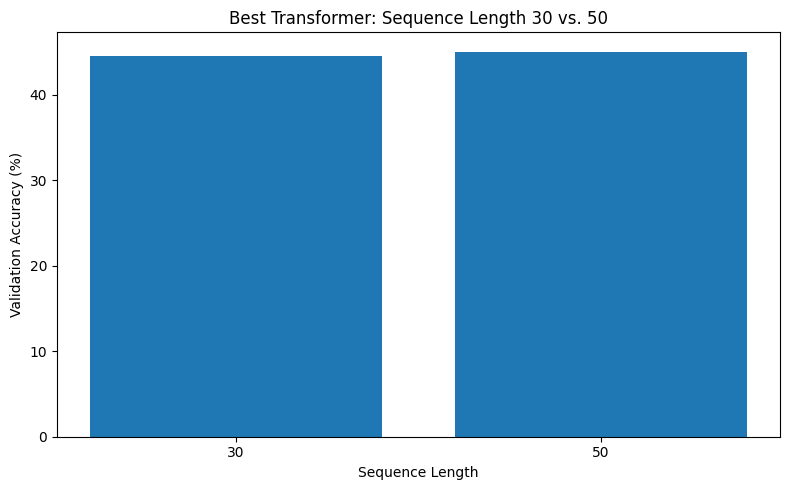

In [38]:
plt.figure(figsize=(8, 5))

plt.bar(
    sequence_30_50_comparison[
        "Sequence Length"
    ].astype(str),
    sequence_30_50_comparison[
        "Validation Accuracy (%)"
    ]
)

plt.xlabel("Sequence Length")
plt.ylabel("Validation Accuracy (%)")
plt.title("Best Transformer: Sequence Length 30 vs. 50")
plt.tight_layout()

plt.savefig(
    "problem2_sequence_30_50_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

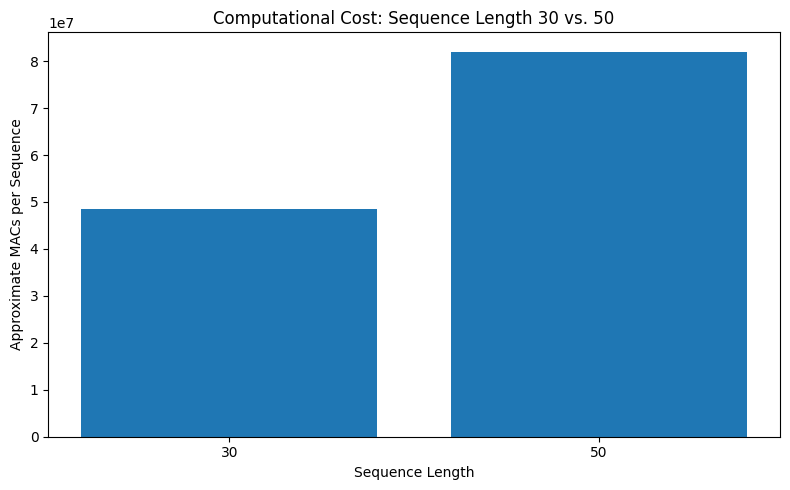

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    sequence_30_50_comparison[
        "Sequence Length"
    ].astype(str),
    sequence_30_50_comparison[
        "Approximate MACs"
    ]
)

plt.xlabel("Sequence Length")
plt.ylabel("Approximate MACs per Sequence")
plt.title("Computational Cost: Sequence Length 30 vs. 50")
plt.tight_layout()

plt.savefig(
    "problem2_sequence_30_50_complexity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
homework2_rnn_results = pd.DataFrame([
    {
        "Model": "LSTM",
        "Sequence Length": 20,
        "Training Loss": 2.291331,
        "Validation Accuracy (%)": 30.15,
        "Training Time (s)": 1.727142,
        "Inference Time (ms)": 0.739503,
        "Parameters": 111873,
        "Model Size (MB)": 0.427,
        "Approximate MACs": 1974400
    },
    {
        "Model": "LSTM",
        "Sequence Length": 30,
        "Training Loss": 2.299169,
        "Validation Accuracy (%)": 29.00,
        "Training Time (s)": 0.936941,
        "Inference Time (ms)": 0.726347,
        "Parameters": 111873,
        "Model Size (MB)": 0.427,
        "Approximate MACs": 2957440
    },
    {
        "Model": "GRU",
        "Sequence Length": 20,
        "Training Loss": 2.181819,
        "Validation Accuracy (%)": 29.85,
        "Training Time (s)": 0.967423,
        "Inference Time (ms)": 0.520685,
        "Parameters": 87041,
        "Model Size (MB)": 0.332,
        "Approximate MACs": 1482880
    },
    {
        "Model": "GRU",
        "Sequence Length": 30,
        "Training Loss": 2.167739,
        "Validation Accuracy (%)": 30.35,
        "Training Time (s)": 1.196761,
        "Inference Time (ms)": 0.753027,
        "Parameters": 87041,
        "Model Size (MB)": 0.332,
        "Approximate MACs": 2220160
    },
    {
        "Model": "LSTM",
        "Sequence Length": 50,
        "Training Loss": 2.294760,
        "Validation Accuracy (%)": 29.45,
        "Training Time (s)": 1.268183,
        "Inference Time (ms)": 0.773395,
        "Parameters": 111873,
        "Model Size (MB)": 0.427,
        "Approximate MACs": 4923520
    },
    {
        "Model": "GRU",
        "Sequence Length": 50,
        "Training Loss": 2.175166,
        "Validation Accuracy (%)": 28.70,
        "Training Time (s)": 0.968209,
        "Inference Time (ms)": 0.609657,
        "Parameters": 87041,
        "Model Size (MB)": 0.332,
        "Approximate MACs": 3694720
    },
    {
        "Model": "GRU Larger Hidden",
        "Sequence Length": 30,
        "Training Loss": 2.047842,
        "Validation Accuracy (%)": 33.30,
        "Training Time (s)": 1.128564,
        "Inference Time (ms)": 0.935624,
        "Parameters": 268161,
        "Model Size (MB)": 1.023,
        "Approximate MACs": 7389440
    }
])

homework2_rnn_results

,Model,Sequence Length,Training Loss,Validation Accuracy (%),Training Time (s),Inference Time (ms),Parameters,Model Size (MB),Approximate MACs
0,LSTM,20,2.291331,30.15,1.727142,0.739503,111873,0.427,1974400
1,LSTM,30,2.299169,29.00,0.936941,0.726347,111873,0.427,2957440
2,GRU,20,2.181819,29.85,0.967423,0.520685,87041,0.332,1482880
3,GRU,30,2.167739,30.35,1.196761,0.753027,87041,0.332,2220160
4,LSTM,50,2.294760,29.45,1.268183,0.773395,111873,0.427,4923520
5,GRU,50,2.175166,28.70,0.968209,0.609657,87041,0.332,3694720
6,GRU Larger Hidden,30,2.047842,33.30,1.128564,0.935624,268161,1.023,7389440


In [41]:
best_transformer_row = ranked_architectures.iloc[0]

transformer_for_comparison = pd.DataFrame([{
    "Model": (
        "Transformer "
        + best_transformer_row["Configuration"]
    ),
    "Sequence Length": best_transformer_row[
        "Sequence Length"
    ],
    "Validation Loss": best_transformer_row[
        "Validation Loss"
    ],
    "Validation Accuracy (%)": best_transformer_row[
        "Validation Accuracy (%)"
    ],
    "Validation Perplexity": best_transformer_row[
        "Validation Perplexity"
    ],
    "Training Time (s)": best_transformer_row[
        "Training Time (s)"
    ],
    "Inference Time (ms)": best_transformer_row[
        "Inference Time (ms)"
    ],
    "Parameters": best_transformer_row[
        "Parameters"
    ],
    "Model Size (MB)": best_transformer_row[
        "Model Size (MB)"
    ],
    "Approximate MACs": best_transformer_row[
        "Approximate MACs"
    ]
}])

transformer_for_comparison

,Model,Sequence Length,Validation Loss,Validation Accuracy (%),Validation Perplexity,Training Time (s),Inference Time (ms),Parameters,Model Size (MB),Approximate MACs
0,Transformer B2_H2_D256,30,1.873781,44.560417,6.512876,27.738718,1.620399,1621057,6.194345,48606720


In [42]:
transformer_vs_rnn = pd.concat(
    [
        homework2_rnn_results,
        transformer_for_comparison
    ],
    ignore_index=True
)

transformer_vs_rnn

,Model,Sequence Length,Training Loss,Validation Accuracy (%),Training Time (s),Inference Time (ms),Parameters,Model Size (MB),Approximate MACs,Validation Loss,Validation Perplexity
0,LSTM,20,2.291331,30.150000,1.727142,0.739503,111873,0.427000,1974400,NaN,NaN
1,LSTM,30,2.299169,29.000000,0.936941,0.726347,111873,0.427000,2957440,NaN,NaN
2,GRU,20,2.181819,29.850000,0.967423,0.520685,87041,0.332000,1482880,NaN,NaN
3,GRU,30,2.167739,30.350000,1.196761,0.753027,87041,0.332000,2220160,NaN,NaN
4,LSTM,50,2.294760,29.450000,1.268183,0.773395,111873,0.427000,4923520,NaN,NaN
5,GRU,50,2.175166,28.700000,0.968209,0.609657,87041,0.332000,3694720,NaN,NaN
6,GRU Larger Hidden,30,2.047842,33.300000,1.128564,0.935624,268161,1.023000,7389440,NaN,NaN
7,Transformer B2_H2_D256,30,NaN,44.560417,27.738718,1.620399,1621057,6.194345,48606720,1.873781,6.512876


In [43]:
transformer_vs_rnn.to_csv(
    "problem2_transformer_vs_rnn.csv",
    index=False
)

print("Saved: problem2_transformer_vs_rnn.csv")

Saved: problem2_transformer_vs_rnn.csv


In [44]:
import shutil

output_files = [
    filename
    for filename in os.listdir(".")
    if filename.startswith("problem2_")
]

os.makedirs(
    "problem2_results",
    exist_ok=True
)

for filename in output_files:
    if os.path.isfile(filename):
        shutil.copy(
            filename,
            os.path.join(
                "problem2_results",
                filename
            )
        )

shutil.make_archive(
    "problem2_results",
    "zip",
    "problem2_results"
)

print("Created: problem2_results.zip")

Created: problem2_results.zip


In [45]:
from google.colab import files

files.download("problem2_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>